In [1]:
# Auskommentieren für eine Installation von gym && gym-bandits in Google Colaboratory
#!pip install gym==0.23 gym-bandits==0.0.1 matplotlib==3.7.1

In [1]:
import os

import gym
import gym_bandits
import numpy as np
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# show available OpenAI Gym environments
from gym import envs
print(envs.registry.all())

ValuesView(├──CartPole: [ v0, v1 ]
├──MountainCar: [ v0 ]
├──MountainCarContinuous: [ v0 ]
├──Pendulum: [ v1 ]
├──Acrobot: [ v1 ]
├──LunarLander: [ v2 ]
├──LunarLanderContinuous: [ v2 ]
├──BipedalWalker: [ v3 ]
├──BipedalWalkerHardcore: [ v3 ]
├──CarRacing: [ v1 ]
├──Blackjack: [ v1 ]
├──FrozenLake: [ v1 ]
├──FrozenLake8x8: [ v1 ]
├──CliffWalking: [ v0 ]
├──Taxi: [ v3 ]
├──Reacher: [ v2 ]
├──Pusher: [ v2 ]
├──InvertedPendulum: [ v2 ]
├──InvertedDoublePendulum: [ v2 ]
├──HalfCheetah: [ v2, v3 ]
├──Hopper: [ v2, v3 ]
├──Swimmer: [ v2, v3 ]
├──Walker2d: [ v2, v3 ]
├──Ant: [ v2, v3 ]
├──Humanoid: [ v2, v3 ]
├──HumanoidStandup: [ v2 ]
└──MultiarmedBandits: [ v0 ]
)


In [46]:
def epsilon_greedy(expParam, Q, arm_count, action_space):
    rand = np.random.random()
    if rand < expParam:
        action = action_space.sample()
    else:
        #action = action_space.start + np.argmax(Q)
        action = np.argmax(Q)
    return action

# DONE Uebung 2: implement logic
def my_softmax(exps):
    exp = np.exp(exps)
    return [e / np.sum(exp) for e in exp]

def softmax (expParam, Q, arm_count, action_space):
    weights = [Q[a] / expParam for a in range(action_space.n)]
    action = np.random.choice(np.arange(action_space.n), p=my_softmax(weights))
    return action

# DONE Uebung 2: implement logic
def ucb (expParam, Q, arm_count, action_space):
    num_arms = 10
    t = np.sum(arm_count)
    A = [Q[a] + expParam * np.sqrt(np.log(t + num_arms) / (arm_count[a] + 1)) for a in range(action_space.n)]
    return np.argmax(A)
    
# DONE Uebung 3: implement custom exploration method. E.g. decay epsilon over time, or anything else 
def custom_method (expParam, Q, arm_count, action_space):
    # exponential decay of epsilon parameter
    current_play = np.sum(arm_count)
    half_life = 100
    epsilon = expParam * (0.5 ** (current_play / half_life))
    return epsilon_greedy(epsilon, Q, arm_count, action_space)

In [47]:
# number of rounds (iterations)
num_plays = 1000
num_experiments = 1000
arms = 10

exploration_parameters = {
    'egreedy':  [0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
    'softmax':  [   0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2, 5, 10, 20, 100],
    'ucb':      [0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2, 5, 10, 20, 100],
    'custom':   [0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
}
expMemory = {
    'egreedy': {},
    'softmax': {},
    'ucb': {},
    'custom': {}
}
exploration_methods = {
    'egreedy': epsilon_greedy,
    'softmax': softmax, 
    'ucb': ucb, 
    'custom': custom_method
}

<function epsilon_greedy at 0x79a20698f060>, param=0


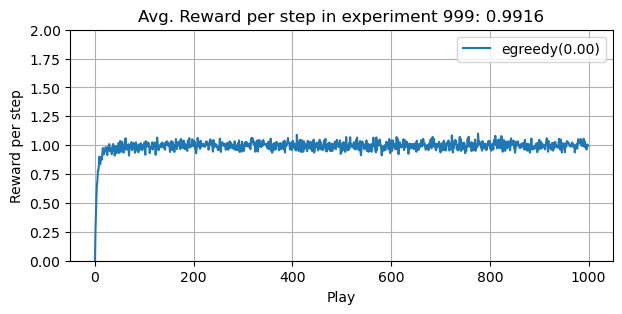

<function epsilon_greedy at 0x79a20698f060>, param=0.01


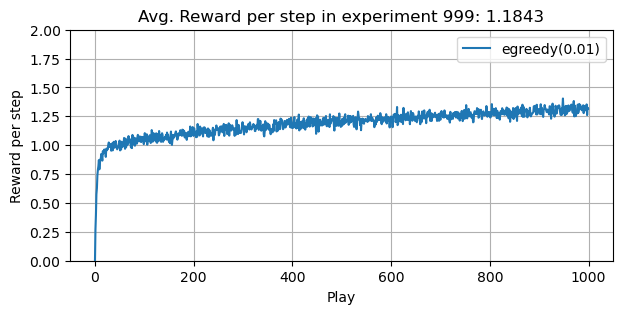

<function epsilon_greedy at 0x79a20698f060>, param=0.05


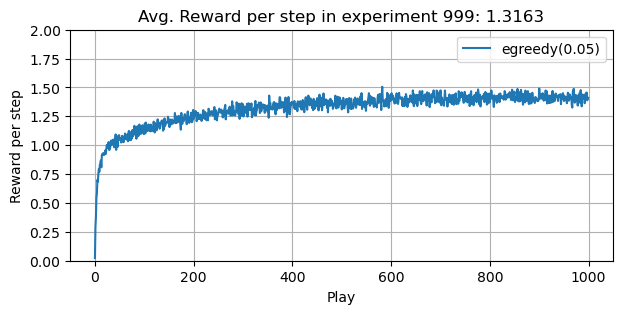

<function epsilon_greedy at 0x79a20698f060>, param=0.1


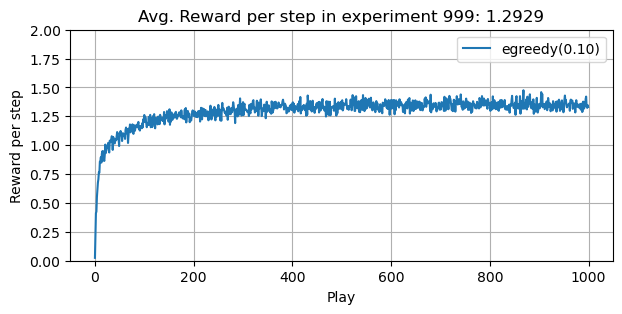

<function epsilon_greedy at 0x79a20698f060>, param=0.2


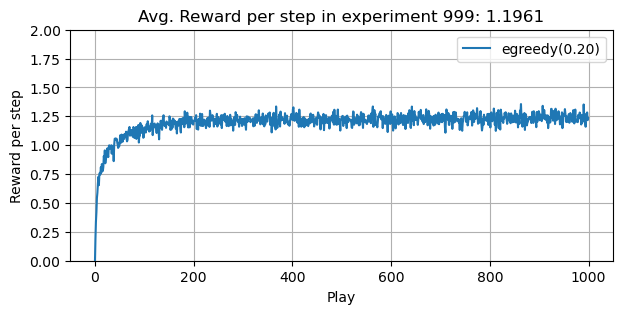

<function epsilon_greedy at 0x79a20698f060>, param=0.5


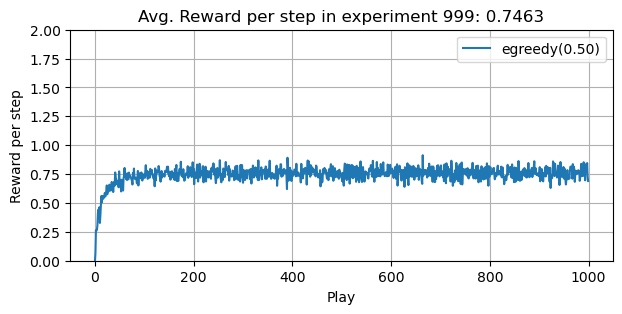

<function epsilon_greedy at 0x79a20698f060>, param=1.0


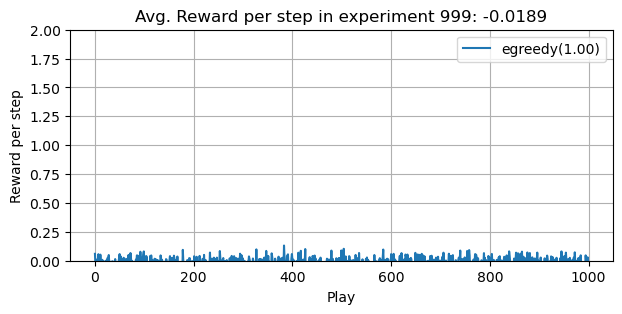

<function softmax at 0x79a20698dee0>, param=0.01


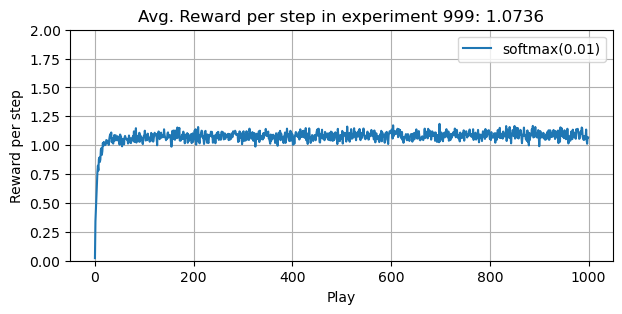

<function softmax at 0x79a20698dee0>, param=0.05


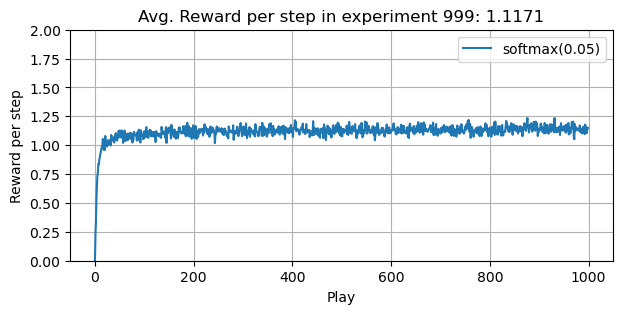

<function softmax at 0x79a20698dee0>, param=0.1


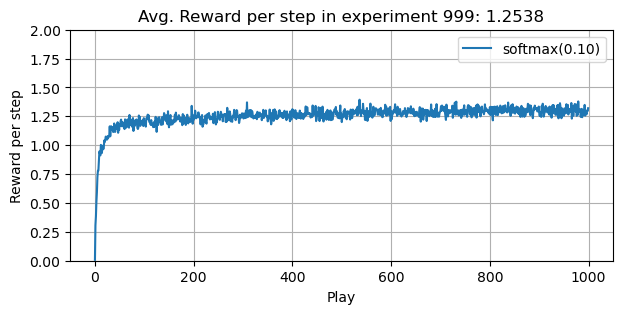

<function softmax at 0x79a20698dee0>, param=0.2


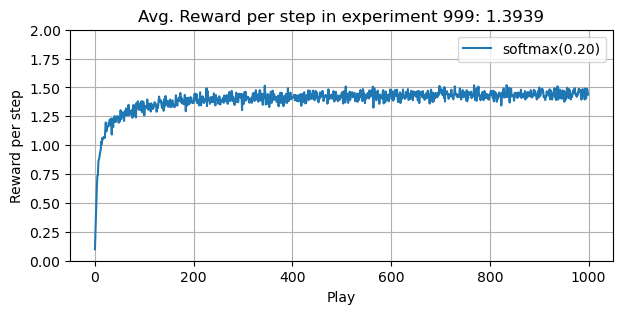

<function softmax at 0x79a20698dee0>, param=0.5


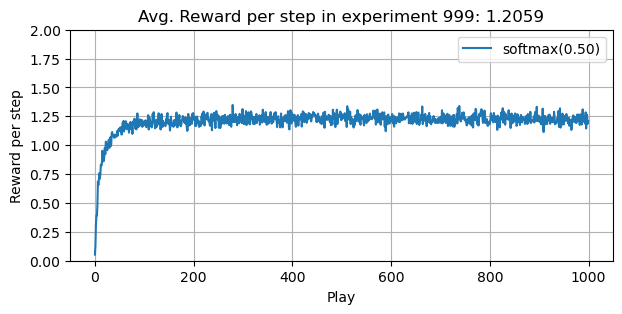

<function softmax at 0x79a20698dee0>, param=1.0


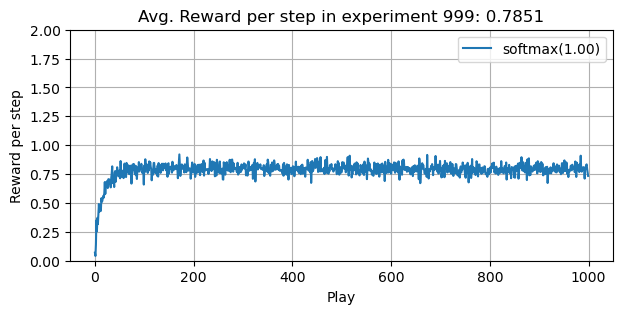

<function softmax at 0x79a20698dee0>, param=2


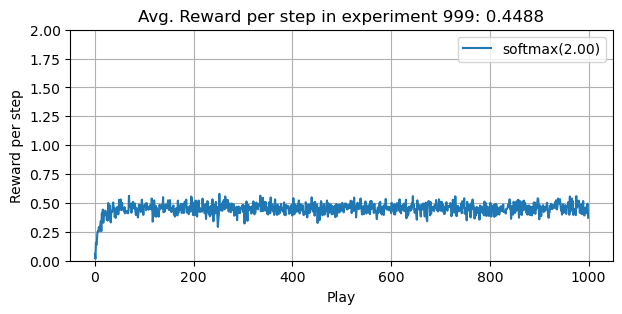

<function softmax at 0x79a20698dee0>, param=5


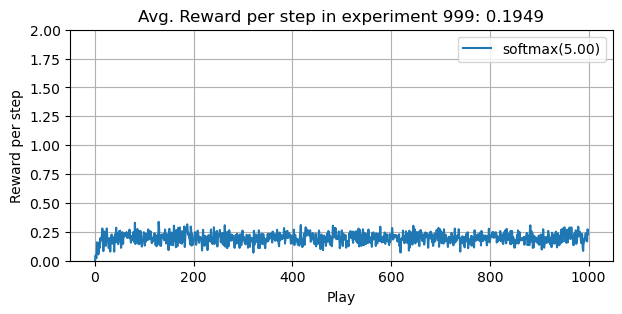

<function softmax at 0x79a20698dee0>, param=10


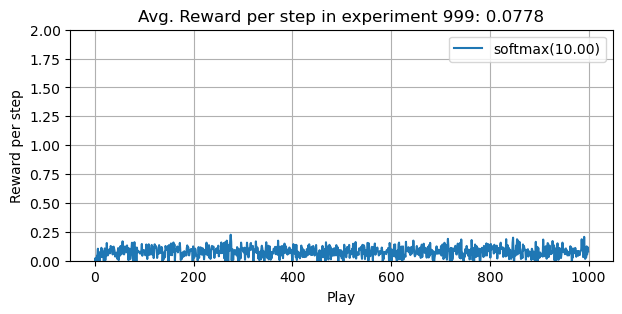

<function softmax at 0x79a20698dee0>, param=20


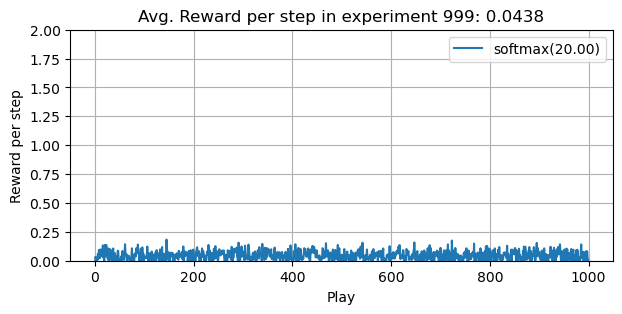

<function softmax at 0x79a20698dee0>, param=100


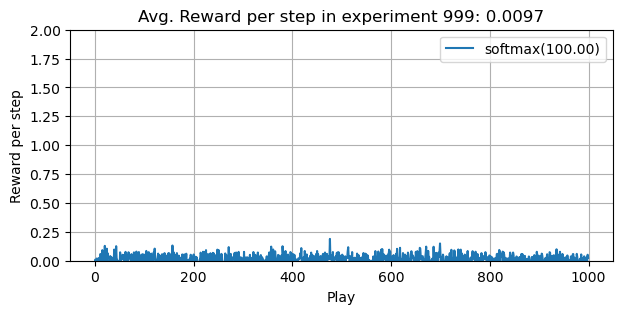

<function ucb at 0x79a20698f2e0>, param=0


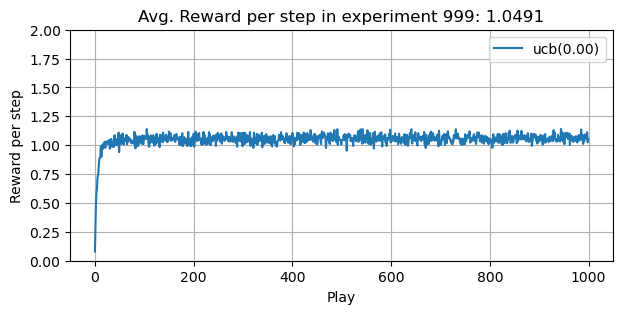

<function ucb at 0x79a20698f2e0>, param=0.01


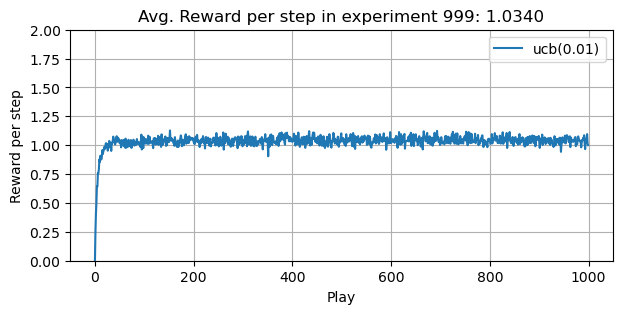

<function ucb at 0x79a20698f2e0>, param=0.05


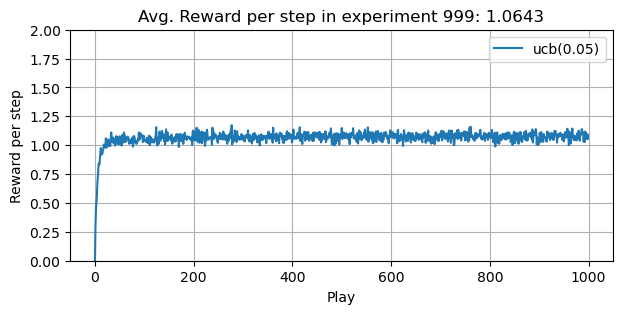

<function ucb at 0x79a20698f2e0>, param=0.1


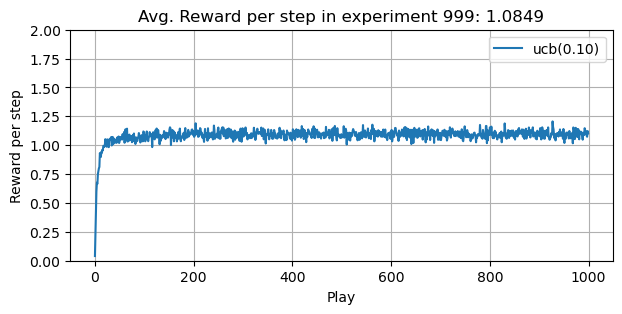

<function ucb at 0x79a20698f2e0>, param=0.2


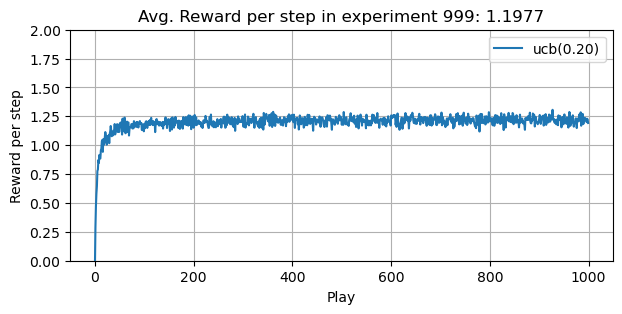

<function ucb at 0x79a20698f2e0>, param=0.5


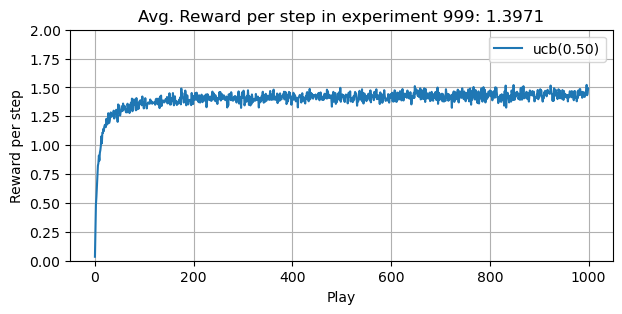

<function ucb at 0x79a20698f2e0>, param=1.0


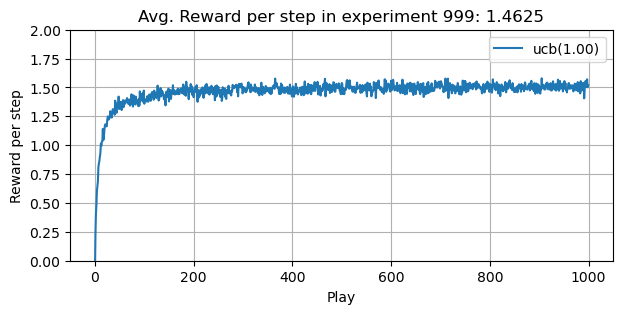

<function ucb at 0x79a20698f2e0>, param=2


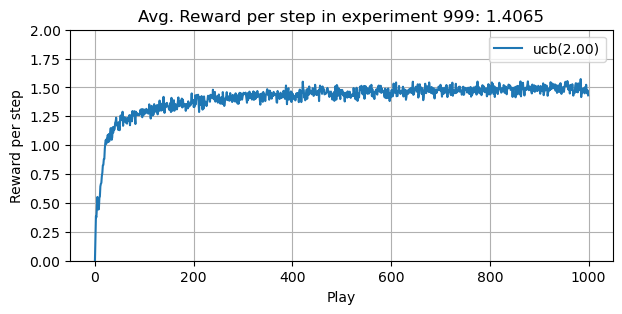

<function ucb at 0x79a20698f2e0>, param=5


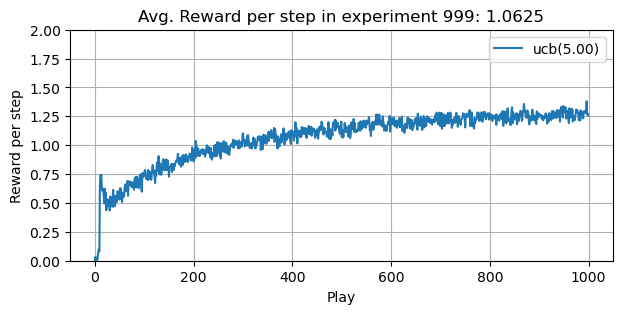

<function ucb at 0x79a20698f2e0>, param=10


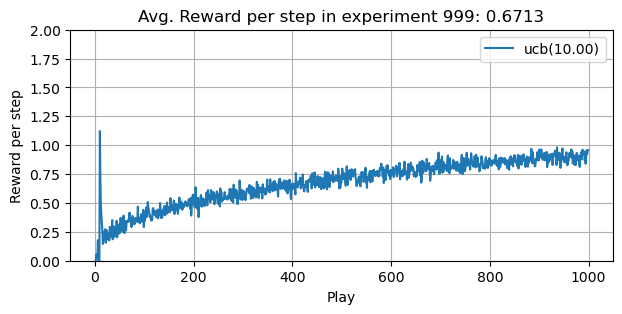

<function ucb at 0x79a20698f2e0>, param=20


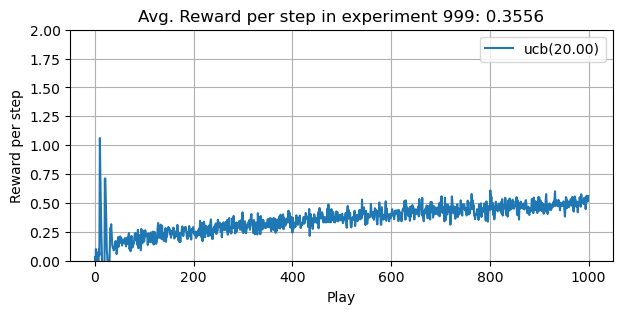

<function ucb at 0x79a20698f2e0>, param=100


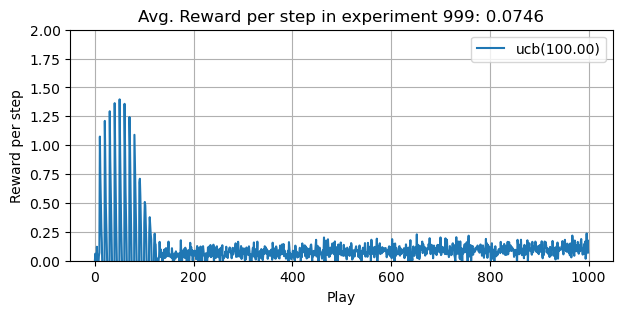

<function custom_method at 0x79a20698fa60>, param=0


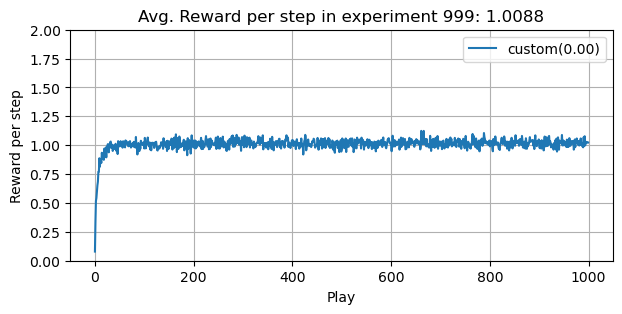

<function custom_method at 0x79a20698fa60>, param=0.01


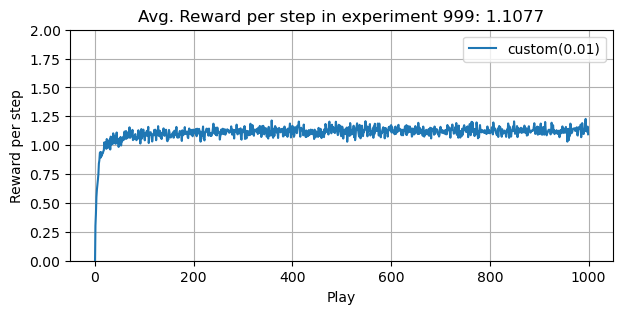

<function custom_method at 0x79a20698fa60>, param=0.05


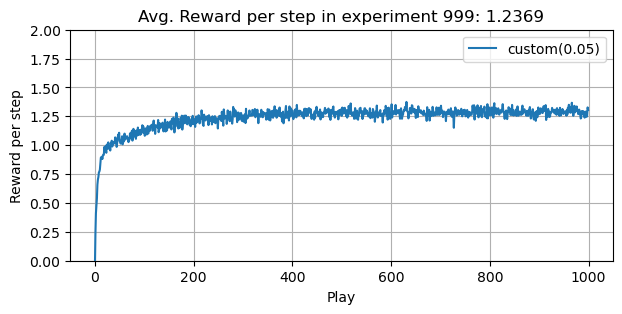

<function custom_method at 0x79a20698fa60>, param=0.1


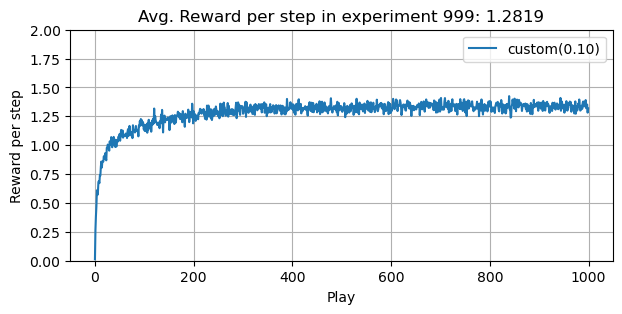

<function custom_method at 0x79a20698fa60>, param=0.2


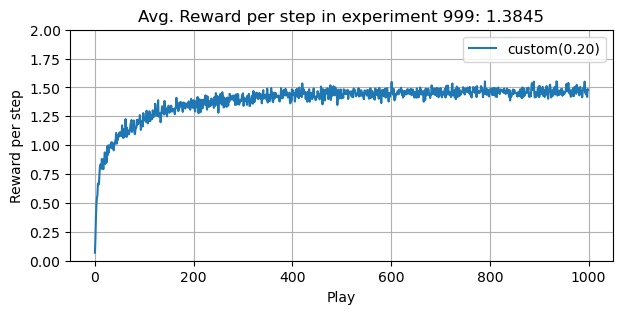

<function custom_method at 0x79a20698fa60>, param=0.5


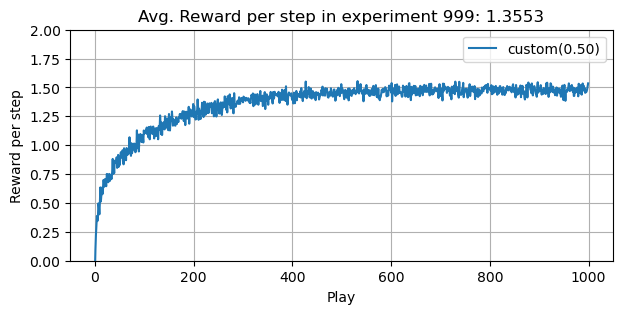

<function custom_method at 0x79a20698fa60>, param=1.0


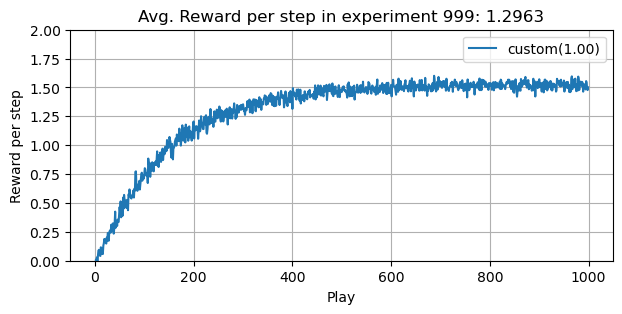

In [48]:
plots_base_path = os.path.join(os.path.curdir, 'plots')
experiments_base_path = os.path.join(plots_base_path, 'experiments')
os.makedirs(plots_base_path, exist_ok=True)
os.makedirs(experiments_base_path, exist_ok=True)

#######################
# conduct experiment
#######################
# exploration_parameters = exp_greedy
for method_name in exploration_methods.keys():
    
    exp_method = exploration_methods[method_name]
    
    for expParam in exploration_parameters[method_name]:
        
        print (f"{exp_method}, param={expParam}")
        
        # memorize all rewards of all episodes in rewardMemory for statistic plotting
        rewardMemory = []
    
        for e in range(num_experiments):

            # create new instance of bandit environment
            env = gym.make("MultiarmedBandits-v0")
            env.reset()

            # count of number of times an arm was pulled
            arm_count = np.zeros(arms)
            # Q value => expected average reward
            Q = np.zeros(arms)
            rewards = np.zeros(num_plays)

            for i in range(num_plays):
                # select action (exploration/exploitation)
                arm = exp_method(expParam=expParam, Q=Q, arm_count=arm_count, action_space=env.action_space)

                # get reward/observation/terminalInfo
                observation, reward, done, info = env.step(arm)
                
                # update the count of that arm
                arm_count[arm] += 1
                
                # DONE Uebung 1: recalculate its Q value
                reward = reward[0]
                Q[arm] = Q[arm] + (reward - Q[arm]) / arm_count[arm]
                
                # memorize rewards per play
                rewards[i] = reward

            # memorize reward array
            rewardMemory.append(rewards)

            ###################
            # Plotting results
            ###################
            if e == (num_experiments-1):

                means = np.mean(rewardMemory, axis=0)

                # plot average reward
                plt.figure(figsize=(7,3))
                plt.plot(means, label="%s(%.2f)" % (method_name, expParam))
                
                plt.ylim(0, 2) # limit y axis
                plt.title('Avg. Reward per step in experiment %d: %.4f' % (e, sum(means) / num_plays))
                plt.ylabel("Reward per step")
                plt.xlabel("Play")
                plt.legend()
                method_path = os.path.join(experiments_base_path, method_name)
                os.makedirs(method_path, exist_ok=True)
                plt.grid()
                plt.savefig(os.path.join(method_path, f'{method_name}_expParam_{expParam}_experiment_{e}.png'))
                plt.show()

        #expMemory[method_name] |= { expParam: rewardMemory }
        expMemory[method_name][expParam] = rewardMemory


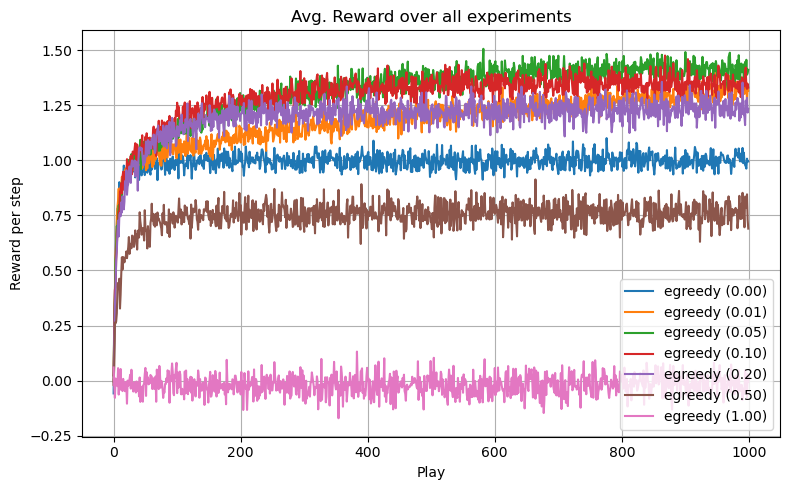

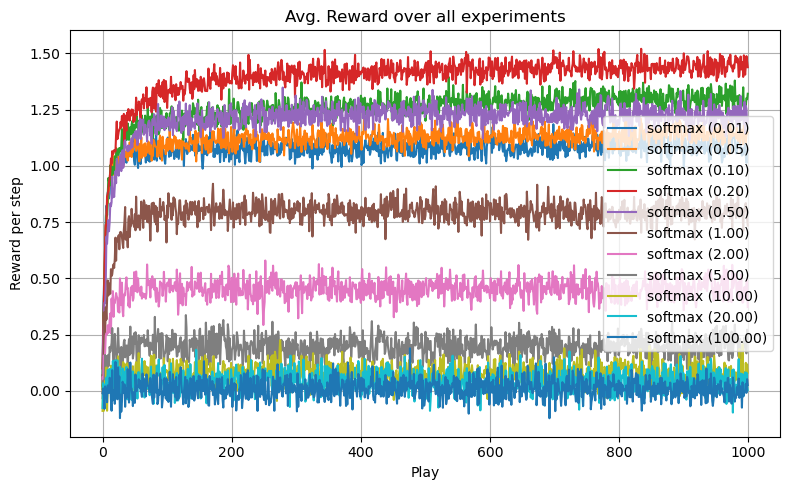

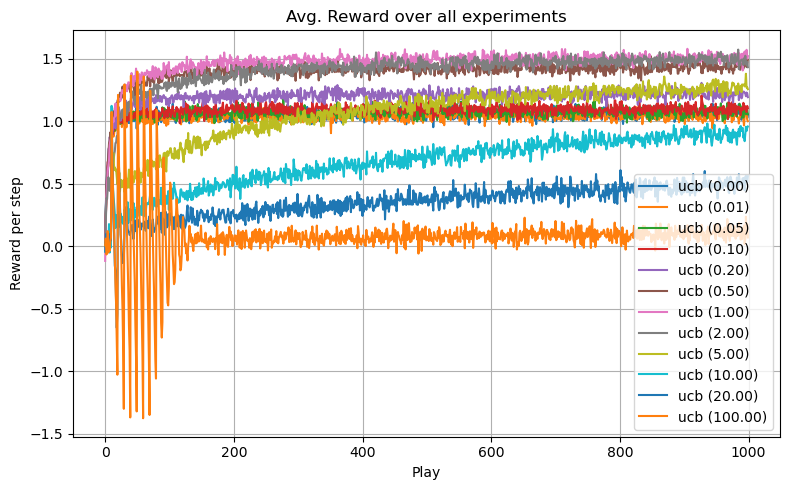

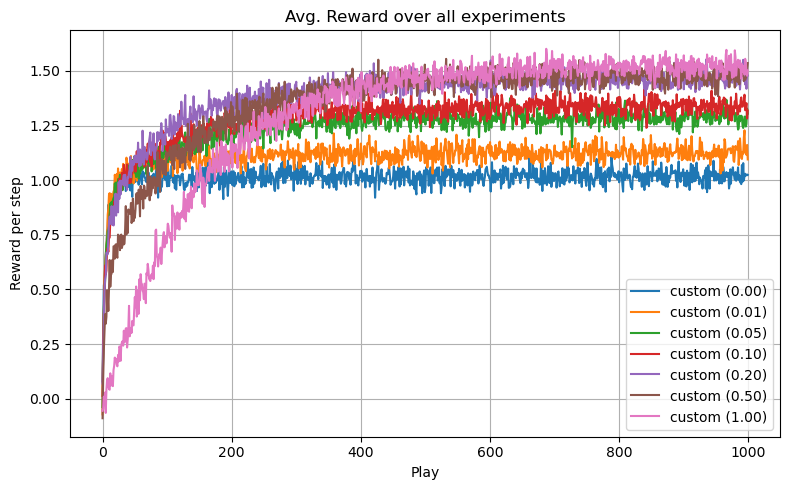

In [49]:
"""
Die Mittelwerte über jeweils 1000 Experimente sollen in einem Graph dargestellt werden
"""
#sns.set_theme(style='white')
for method_name in exploration_methods.keys():
    _ = plt.figure(figsize=(8, 5))
    plt.set_cmap('Set3')
    for expParam, memory in expMemory[method_name].items():
        means = np.mean(memory, axis=0)
        plt.plot(means, label=f'{method_name} ({expParam:.2f})')

    plt.grid()
    plt.xlabel('Play')
    plt.ylabel('Reward per step')
    plt.title('Avg. Reward over all experiments')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(plots_base_path, f'{method_name}.png'))
    plt.show()

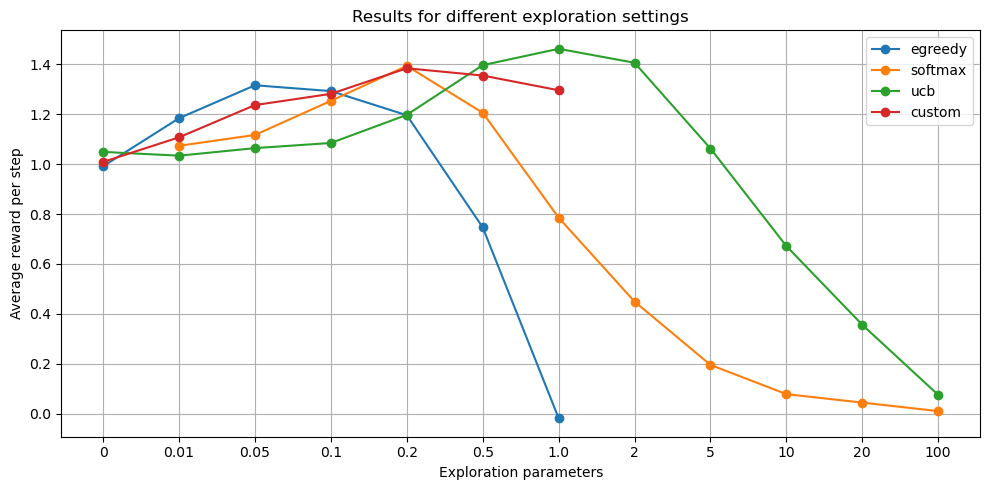

In [50]:
"""
Was sind gute Parameter, was sind schlechte Parameter?
Belegen Sie Ihre Aussage mit statistischen Auswertungen.
Erstellen Sie einen Scatter-Plot der Ergebnisse aller drei
Explorationsverfahren nach folgenden Vorgaben:

X-Achse: Explorationsparameter des jeweiligen Explorationsverfahrens

Y-Achse: durchschnittlicher Reward pro Schritt in einer Episode der
         Länge von 1000 Schritten, gemittelt über 1000 Experimente.
"""
_ = plt.figure(figsize=(10, 5))
for method_name in exploration_methods.keys():
    x, y = [], []
    for expParam, experiments_rewards in expMemory[method_name].items():
        x.append(str(expParam))
        play_means = []
        for plays_rewards in experiments_rewards:
            play_means.append(np.mean(plays_rewards))
        y.append(np.mean(play_means))
    plt.plot(x, y, linestyle="-", marker="o", label=method_name)

plt.grid()
plt.xlabel('Exploration parameters')
plt.ylabel('Average reward per step')
plt.title('Results for different exploration settings')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_base_path, 'aggregated.png'))
plt.show()